# 03 — Feature Analysis
**Cash Flow & AR Collection Intelligence System**

Goal: Validate that engineered features carry real signal before training.
Every feature that goes into the model should have a financial justification.

Sections:
1. Feature store overview
2. Correlation analysis
3. Feature vs target relationship
4. Class balance check
5. Feature selection shortlist

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.config import FEATURE_STORE_PATH, TRAIN_PATH, TEST_PATH, CLASSIFIER_CFG

sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:,.4f}'.format)

def _safe_read_csv(path, **kwargs):
    path = Path(path)
    if path.exists() and path.stat().st_size > 0:
        return pd.read_csv(path, **kwargs)
    return None

fs = _safe_read_csv(FEATURE_STORE_PATH, parse_dates=['BLDAT'])
if fs is None:
    raise FileNotFoundError('No usable processed feature_store found. Run: python -m src.data.features')

def _safe_read_split(path):
    return _safe_read_csv(path)

train = _safe_read_split(TRAIN_PATH)
test = _safe_read_split(TEST_PATH)
if train is None or test is None:
    split_idx = int(len(fs) * (1 - CLASSIFIER_CFG.test_size))
    train = fs.iloc[:split_idx].copy()
    test = fs.iloc[split_idx:].copy()
    print('Processed train/test not found or empty; using on-the-fly split from feature_store.')

print(f'Feature store: {fs.shape}')
print(f'Train:         {train.shape}')
print(f'Test:          {test.shape}')
print(f'Features:      {CLASSIFIER_CFG.feature_cols}')

Feature store: (4995, 35)
Train:         (3996, 35)
Test:          (999, 35)
Features:      ['LOG_AMOUNT', 'PAYMENT_DAYS_NUM', 'INDUSTRY_CODE', 'REGION_CODE', 'CUST_AVG_DAYS_LATE', 'CUST_LATE_RATE', 'CUST_INVOICE_COUNT', 'CUST_AVG_AMOUNT', 'INVOICE_MONTH', 'INVOICE_QUARTER', 'INVOICE_DOW', 'IS_QUARTER_END']


## 1. Feature Store Overview

In [8]:
# Missing values check
missing = fs[CLASSIFIER_CFG.feature_cols].isnull().sum()
print('Missing values per feature:')
print(missing[missing > 0] if missing.any() else 'None — all features complete')

# Descriptive stats
fs[CLASSIFIER_CFG.feature_cols].describe().T

Missing values per feature:
None — all features complete


,count,mean,std,min,25%,50%,75%,max
LOG_AMOUNT,"4,995.0000",11.4552,0.9236,6.9315,11.0730,11.7413,12.1400,12.4291
PAYMENT_DAYS_NUM,"4,995.0000",46.5359,25.5557,14.0000,30.0000,45.0000,60.0000,90.0000
INDUSTRY_CODE,"4,995.0000",2.6036,1.7131,0.0000,1.0000,3.0000,4.0000,5.0000
REGION_CODE,"4,995.0000",1.9792,1.4508,0.0000,1.0000,2.0000,3.0000,4.0000
CUST_AVG_DAYS_LATE,"4,995.0000",7.9174,8.8111,-5.0000,1.5000,2.8095,12.1194,47.0000
CUST_LATE_RATE,"4,995.0000",0.7379,0.2574,0.0000,0.6000,0.7857,0.9524,1.0000
CUST_INVOICE_COUNT,"4,995.0000",12.5387,8.0982,0.0000,6.0000,12.0000,19.0000,40.0000
CUST_AVG_AMOUNT,"4,995.0000","123,857.1470","30,564.8303","1,706.0500","109,091.6942","125,026.9394","139,054.7186","249,539.5000"
INVOICE_MONTH,"4,995.0000",6.0747,3.4281,1.0000,3.0000,6.0000,9.0000,12.0000
INVOICE_QUARTER,"4,995.0000",2.3588,1.1049,1.0000,1.0000,2.0000,3.0000,4.0000


## 2. Correlation Analysis

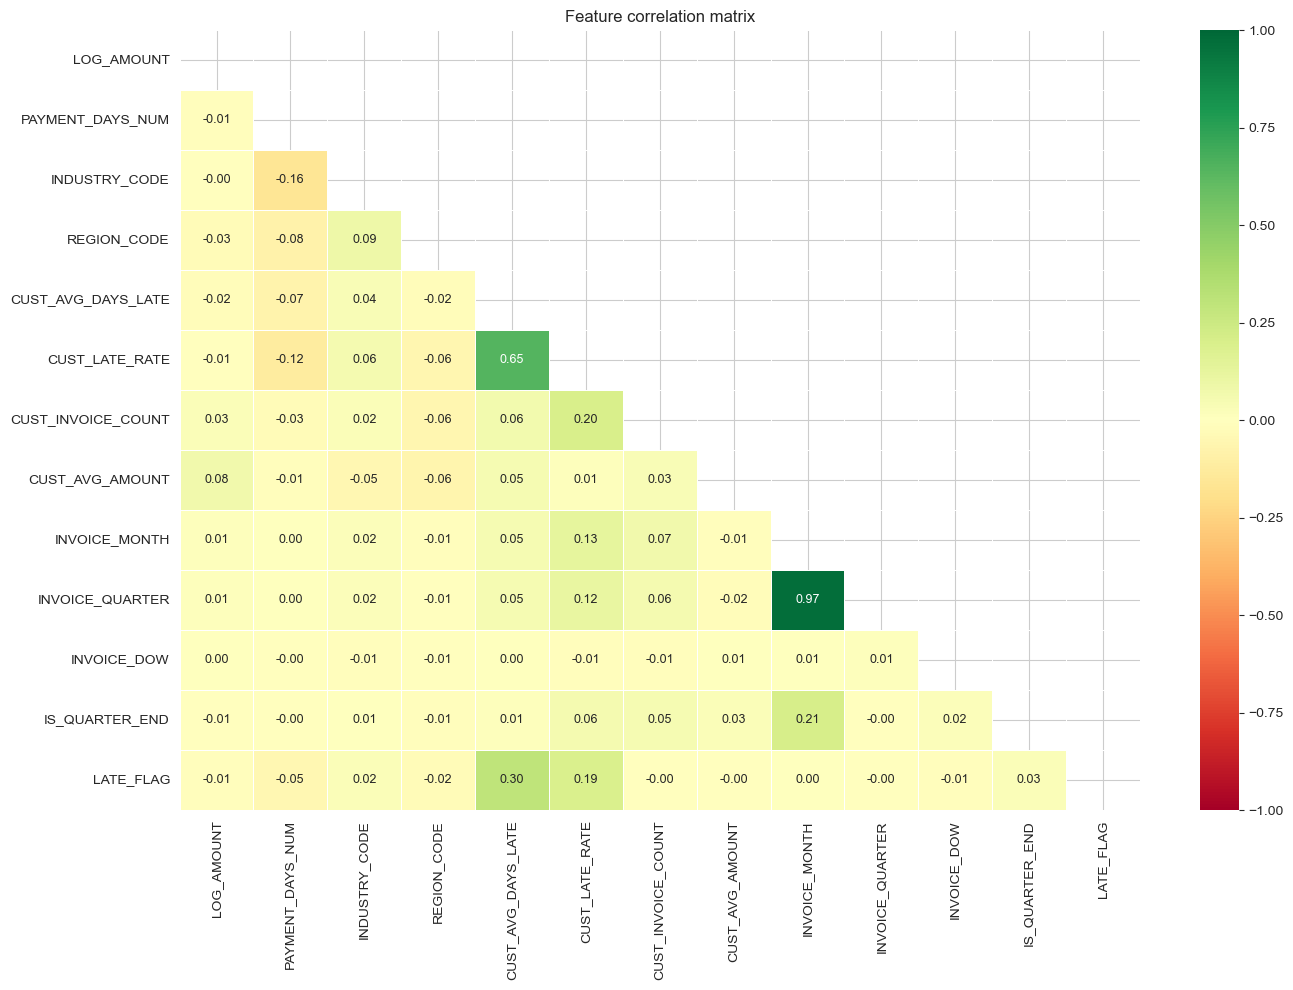


Correlation with LATE_FLAG:
CUST_AVG_DAYS_LATE    0.2970
CUST_LATE_RATE        0.1940
PAYMENT_DAYS_NUM     -0.0540
IS_QUARTER_END        0.0280
INDUSTRY_CODE         0.0240
REGION_CODE          -0.0240
LOG_AMOUNT           -0.0110
INVOICE_DOW          -0.0080
INVOICE_QUARTER      -0.0030
CUST_INVOICE_COUNT   -0.0000
INVOICE_MONTH         0.0000
CUST_AVG_AMOUNT      -0.0000
Name: LATE_FLAG, dtype: float64


In [9]:
# Correlation heatmap — features + target
corr_cols = CLASSIFIER_CFG.feature_cols + ['LATE_FLAG']
corr = fs[corr_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

# Features most correlated with target
target_corr = corr['LATE_FLAG'].drop('LATE_FLAG').sort_values(key=abs, ascending=False)
print('\nCorrelation with LATE_FLAG:')
print(target_corr.round(3))

## 3. Feature vs Target Relationship

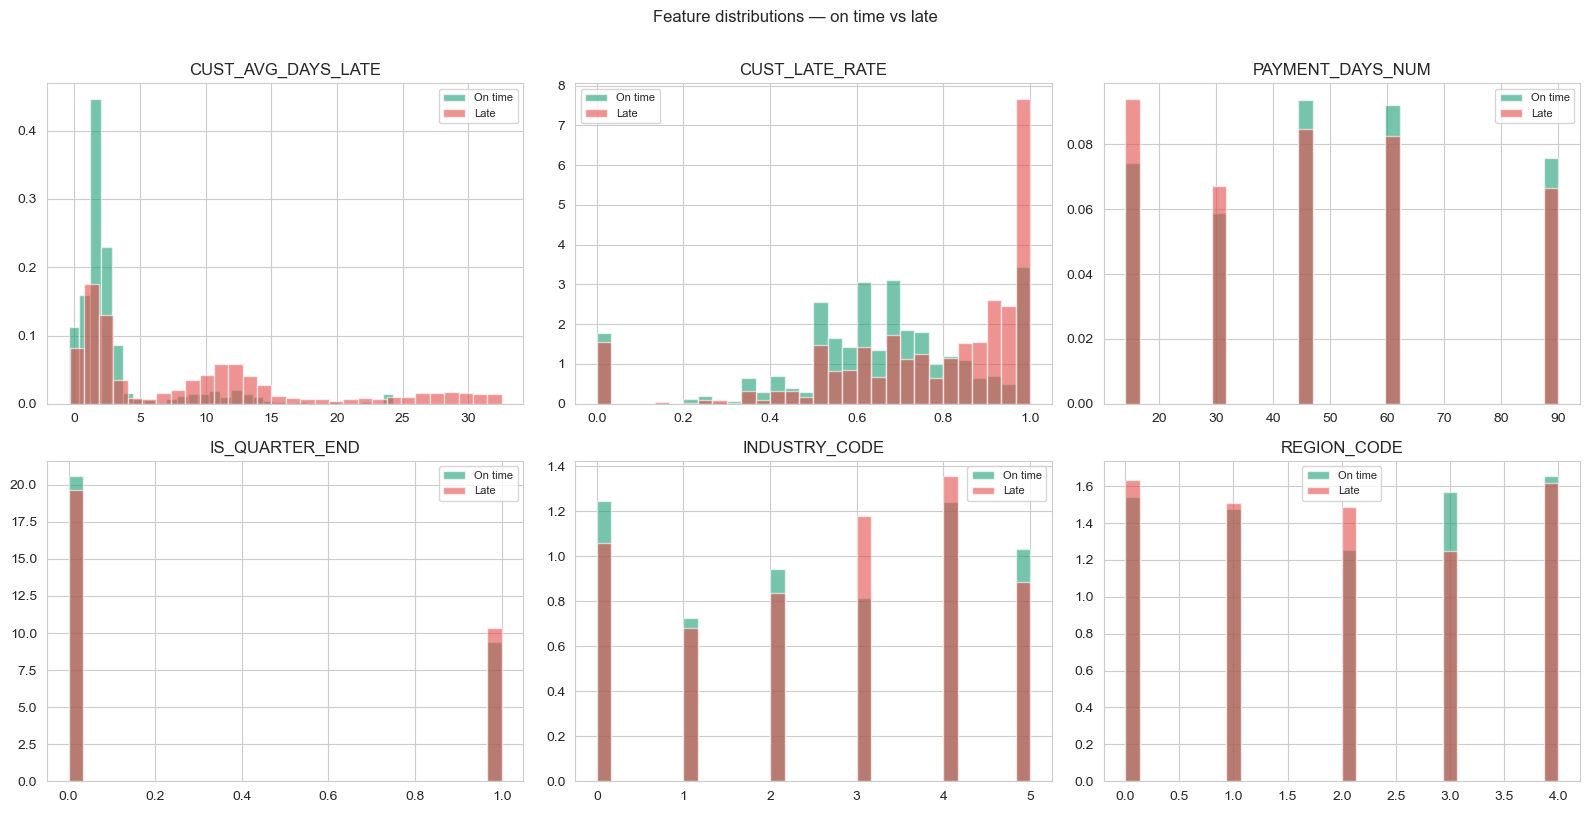

In [10]:
# Mean of each feature by late/on-time — do features separate the classes?
top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    late_vals    = fs[fs['LATE_FLAG'] == 1][feat].dropna()
    ontime_vals  = fs[fs['LATE_FLAG'] == 0][feat].dropna()
    axes[i].hist(ontime_vals.clip(*np.percentile(ontime_vals, [1,99])),
                 bins=30, alpha=0.6, label='On time', color='#1D9E75', density=True)
    axes[i].hist(late_vals.clip(*np.percentile(late_vals, [1,99])),
                 bins=30, alpha=0.6, label='Late', color='#E24B4A', density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature distributions — on time vs late', y=1.01)
plt.tight_layout()
plt.show()
# Good feature: distributions should be visibly different between classes

## 4. Class Balance Check

In [11]:
for split_name, split_df in [('Train', train), ('Test', test)]:
    late_n  = split_df['LATE_FLAG'].sum()
    total   = len(split_df)
    late_pct = late_n / total
    spw     = round((1 - late_pct) / late_pct, 1)  # recommended scale_pos_weight
    print(f'{split_name}: {total:,} rows  |  late: {int(late_n):,} ({late_pct:.1%})  |  recommended scale_pos_weight: {spw}')

Train: 3,996 rows  |  late: 3,066 (76.7%)  |  recommended scale_pos_weight: 0.3
Test: 999 rows  |  late: 782 (78.3%)  |  recommended scale_pos_weight: 0.3


## 5. Feature Selection Shortlist

In [12]:
# Features to use in model — with financial justification
feature_rationale = {
    'LOG_AMOUNT':               'Larger invoices = more approval steps = slower payment',
    'PAYMENT_DAYS_NUM':         'Longer terms = more payment events = higher late rate',
    'INDUSTRY_CODE':            'Industry sector drives payment culture (energy vs retail)',
    'REGION_CODE':              'Regional payment behavior differences',
    'CUST_AVG_DAYS_LATE':       'STRONGEST signal — past behavior predicts future behavior',
    'CUST_LATE_RATE':           'What % of this customer history is late?',
    'CUST_INVOICE_COUNT':       'New customers are higher risk — less history to assess',
    'CUST_AVG_AMOUNT':          'Baseline for this customer — large deviation = anomaly',
    'INVOICE_MONTH':            'Seasonal payment patterns — Dec/Jan slowdowns',
    'INVOICE_QUARTER':          'Quarter-end = customer closing own books = slower payment',
    'INVOICE_DOW':              'Monday invoices sit in inbox longer over weekend',
    'IS_QUARTER_END':           'Binary flag for Q-end months — high signal',
}

print('Feature shortlist with financial rationale:')
print('─' * 65)
for feat, reason in feature_rationale.items():
    corr_val = corr['LATE_FLAG'].get(feat, float('nan'))
    print(f'{feat:<30} corr={corr_val:+.3f}  |  {reason}')

Feature shortlist with financial rationale:
─────────────────────────────────────────────────────────────────
LOG_AMOUNT                     corr=-0.011  |  Larger invoices = more approval steps = slower payment
PAYMENT_DAYS_NUM               corr=-0.054  |  Longer terms = more payment events = higher late rate
INDUSTRY_CODE                  corr=+0.024  |  Industry sector drives payment culture (energy vs retail)
REGION_CODE                    corr=-0.024  |  Regional payment behavior differences
CUST_AVG_DAYS_LATE             corr=+0.297  |  STRONGEST signal — past behavior predicts future behavior
CUST_LATE_RATE                 corr=+0.194  |  What % of this customer history is late?
CUST_INVOICE_COUNT             corr=-0.000  |  New customers are higher risk — less history to assess
CUST_AVG_AMOUNT                corr=-0.000  |  Baseline for this customer — large deviation = anomaly
INVOICE_MONTH                  corr=+0.000  |  Seasonal payment patterns — Dec/Jan slowdowns
INVOICE